# Compare merged_results.fits with Virgo Catalogs

In [41]:
import os
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.table import Table

from hapy.utils.results_table import prepare_analysis_table
from hapy.utils import plotting

import warnings
warnings.filterwarnings("ignore")

In [5]:
def KE_SFR(haflux, redshift):
    from astropy.cosmology import WMAP9 as cosmo
    # SFR conversion from Kennicutt and Evans (2012)
    # log (dM/dt/Msun/yr) = log(Lx) - logCx
    logCx = 41.27
    #print(len(self.hafit.total_flux),len(self.gzdist))
    L = haflux*(4.*np.pi*cosmo.luminosity_distance(redshift).cgs.value**2)
    #print(L)
    detect_flag = L > 0
    sfr = np.zeros(len(L),'d')
    sfr[detect_flag] = np.log10(L[detect_flag]) - logCx
    return sfr

In [42]:
%run ~/github/Virgo/programs/readtablesv2.py
ssfr = v.cigale['bayes.sfh.sfr'] / v.cigale['bayes.stellar.m_star']

logsfr = np.log10(v.cigale['bayes.sfh.sfr'])
logmstar = np.log10(v.cigale['bayes.stellar.m_star'])
logssfr = logsfr - logmstar


table directory =  /Users/rfinn/research/Virgo/tables-north/v2/


In [31]:
infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417/merged_results_virgo_20260502.fits'

cinfile = '/Users/rfinn/research/Virgo/koopmann-images/hapy_results/cluster/hapy-output-20260430/merged_results_archive_20260430.fits'

%run ~/github/hapy/scripts/science_morphology.py $infile --scheme virgo --ctable $cinfile

tabs = [tab, ctab, trunctab]

for i in range(len(tabs)):
    tabs[i]["logmstar"] = logmstar[tabs[i]["VFINDEX"]]
    tabs[i]["logsfr"] = logsfr[tabs[i]["VFINDEX"]]
    tabs[i]["logssfr"] = logssfr[tabs[i]["VFINDEX"]]

    haflux = tabs[i]['H_TOT_FLUX_CGS']
    redshift = v.main['vr'][tabs[i]['VFINDEX']]/3.e5
    hapy_sfr = KE_SFR(haflux,redshift)
    tabs[i]["hapy_sfr"]= hapy_sfr
    
def get_sci_flag(tab):
    sel = (
        #(tab['QC_TIER'] <= 'D') &                     # A or B only
        (tab['CLEAN']) &                # exclude CAUTION/TBD
        (tab['MASK_OK']) &
        (tab['PHOT_OK']) &
        (tab['R_PROFILE_OK']) &
        (tab['H_PROFILE_OK']) &
        (tab['ELLIP_SMA_PIX'] > 5) &                  # avoid tiny objects
        np.isfinite(tab['R50_ARCSEC']) &
        np.isfinite(tab['H50_ARCSEC']) & 
        (tab['H_HAPY_SNP_DET'] > 2) & 
        (tab["logmstar"] > 8)
    )
    return sel
tabs = [tab, ctab, trunctab]
for t in tabs:
    print(np.sum(get_sci_flag(t)),len(t))
stab = tab[get_sci_flag(tab)]
sctab = ctab[get_sci_flag(ctab)]
strunctab = trunctab[get_sci_flag(trunctab)]



Read 784 rows from /Users/rfinn/research/Virgo/hatools_test/hapy-output-20260417/merged_results_virgo_20260502.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 95, 'low': 283, 'medium': 406}
ELL_MISMATCH 235
FILTER_WARNING 76
WARN_MASK 11
BRIGHT_STAR_FLAG 4
WARN_WEAK_HA 278

Reading cluster table

UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 17, 'low': 7, 'medium': 34}
ELL_MISMATCH 19
FILTER_WARNING 0
WARN_MASK 2
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 2
478 784
42 58
4 4


In [ ]:
# For Becky

cinfile = '/Users/rfinn/research/Virgo/koopmann-images/hapy_results/cluster/hapy-output-20260430/merged_results_archive_20260430.fits'

%run ~/github/hapy/scripts/science_morphology.py $infile --scheme agc

# the table with science and qc columns can now be accessed as tab


def get_sci_flag(tab):
    sel = (
        #(tab['QC_TIER'] <= 'D') &                     # A or B only
        (tab['CLEAN']) &                # exclude CAUTION/TBD
        (tab['MASK_OK']) &
        (tab['PHOT_OK']) &
        (tab['R_PROFILE_OK']) &
        (tab['H_PROFILE_OK']) &
        (tab['ELLIP_SMA_PIX'] > 5) &                  # avoid tiny objects
        np.isfinite(tab['R50_ARCSEC']) &
        np.isfinite(tab['H50_ARCSEC']) & 
        (tab['H_HAPY_SNP_DET'] > 3) & 
    )
    return sel

# this is the restricted table 
stab = tab[get_sci_flag(tab)]


# Compare Ha SFR with magphys

{'INT', 'HDI', 'MOS', 'BOK'}
med offset = 0.10091155699011556


(-4.0, 1.0, -4.0, 1.0)

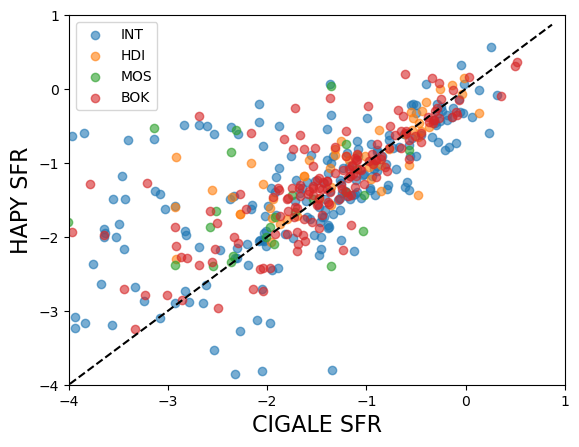

In [62]:
tels = set(stab['TELESCOPE'])
print(tels)
haflux = stab['H_TOT_FLUX_CGS']
redshift = v.main['vr'][stab['VFINDEX']]/3.e5
hapy_sfr = KE_SFR(haflux,redshift)
plt.figure()


x = logsfr[stab['VFINDEX']]
y = hapy_sfr
for t in tels:
    flag = (stab['TELESCOPE'] == t) & (haflux > 0)
    plt.scatter(x[flag],y[flag],label=t,alpha=0.6)
xline = np.linspace(-5,0.5,100)
#plt.plot(xline,xline,'k--')
#plt.plot(xline,xline-1,'k--')
#plt.axhline(y=0,ls='--',c='k')
plt.legend()
plt.xlabel("CIGALE SFR",fontsize=16)
plt.ylabel("HAPY SFR",fontsize=16)
x1, x2 = plt.xlim()
xline = np.linspace(x1,x2,100)
plt.plot(xline,xline,'k--')
print(f"med offset = {np.median(y[flag] - x[flag])}")

plt.axis([-4,1,-4,1])

{'INT', 'HDI', 'MOS', 'BOK'}
med offset = 0.10091155699011556


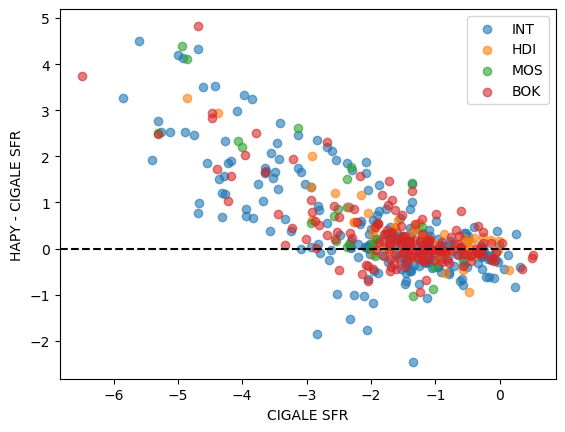

In [59]:
tels = set(stab['TELESCOPE'])
print(tels)
haflux = stab['H_TOT_FLUX_CGS']
redshift = v.main['vr'][stab['VFINDEX']]/3.e5
hapy_sfr = KE_SFR(haflux,redshift)
plt.figure()


x = logsfr[stab['VFINDEX']]
y = hapy_sfr
for t in tels:
    flag = (stab['TELESCOPE'] == t) & (haflux > 0)
    plt.scatter(x[flag],y[flag] - x[flag],label=t,alpha=0.6)
xline = np.linspace(-5,0.5,100)
#plt.plot(xline,xline,'k--')
#plt.plot(xline,xline-1,'k--')
plt.axhline(y=0,ls='--',c='k')
plt.legend()
plt.xlabel("CIGALE SFR")
plt.ylabel("HAPY - CIGALE SFR")
print(f"med offset = {np.median(y[flag] - x[flag])}")

g = plotting.jointplot_with_hue(x,y-x,stab['TELESCOPE'])
g.ax_joint.set_xlim(-5, .5)
g.ax_joint.set_ylim(-1.5, 1.5)
g.ax_joint.axhline(c='k',ls='--')

g.ax_joint.set_ylabel("HAPY - CIGALE SFR",fontsize=12)
g.ax_joint.set_xlabel("CIGALE SFR",fontsize=12)

In [24]:
1200/180

6.666666666666667

/var/folders/d_/xbzntjjj2rz0d1tfc4s267ww0000gq/T/ipykernel_31227/2985224841.py:3: RuntimeWarning: divide by zero encountered in log10
  x = 22.5 - 2.5*np.log10(v.ephot['FLUX_SB24_R'])
/var/folders/d_/xbzntjjj2rz0d1tfc4s267ww0000gq/T/ipykernel_31227/2985224841.py:3: RuntimeWarning: invalid value encountered in log10
  x = 22.5 - 2.5*np.log10(v.ephot['FLUX_SB24_R'])


(-0.5, 0.5)

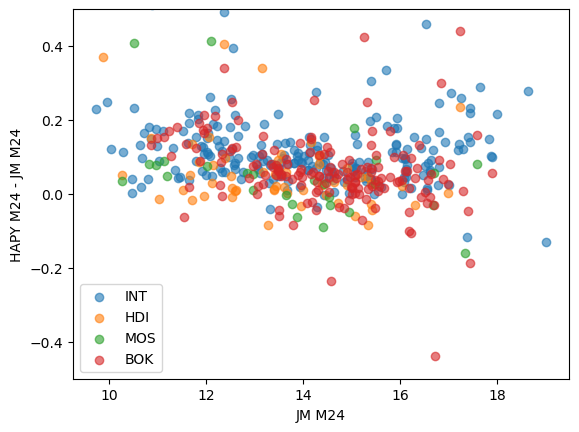

In [33]:
vfindex = stab['VFINDEX']
plt.figure()
x = 22.5 - 2.5*np.log10(v.ephot['FLUX_SB24_R'])
x = x[vfindex]
y = stab['R24_MAG']
xlabel="JM M24"
ylabel="HAPY M24"
#xmin, xmax = 10, 22
for t in tels:
    flag = stab['TELESCOPE'] == t
    plt.scatter(x[flag],y[flag]-x[flag],label=t,alpha=.6)
xmin, xmax = plt.xlim()
xline = np.linspace(xmin,xmax,100)
#plt.plot(xline,xline,'k--')
plt.legend()
plt.xlabel(xlabel)
plt.ylabel(ylabel+" - "+xlabel)

plt.ylim(-.5,.5)

In [45]:
10**1.3

19.952623149688797